In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from BCI2000Tools.FileReader import bcistream

In [2]:
# Change this to your .dat file path
DAT_PATH = Path(r"C:\Users\gabri\Desktop\joystick_test_env\python_da\NameS001R13.dat")

if not DAT_PATH.is_file():
    raise FileNotFoundError(f"File not found: {DAT_PATH}")

print(f"Using: {DAT_PATH.resolve()}")

Using: C:\Users\gabri\Desktop\joystick_test_env\python_da\NameS001R13.dat


Explore the states

In [4]:
stream = bcistream(str(DAT_PATH))

params = stream.params

JOYSTICK_STATES = {
    "x": "JoystickXpos",
    "y": "JoystickYpos",
    "button": "JoystickButtons1",
}

missing_states = [
    name
    for name in JOYSTICK_STATES.values()
    if name not in stream.statedefs
]

app_chain = params.get("ApplicationFilterChain", [])
app_modules = [row[0] for row in app_chain] if app_chain else []

print(f"File: {DAT_PATH.resolve()}")
print(
    f"Recording: {stream.nchan} channels, "
    f"{stream.samples()} samples @ {stream.samplingfreq_hz} Hz"
)
print(
    f"Application modules: "
    f"{', '.join(app_modules) if app_modules else '(none)'}"
)

print()

if not missing_states:
    print("RESULT: YES - joystick X, Y, and button data are present.")
else:
    print("RESULT: INCOMPLETE - some required joystick states are missing.")

print(f"  X state:      {JOYSTICK_STATES['x']}")
print(f"  Y state:      {JOYSTICK_STATES['y']}")
print(f"  Button state: {JOYSTICK_STATES['button']}")

if missing_states:
    print(f"\nMissing states: {', '.join(missing_states)}")

File: C:\Users\gabri\Desktop\joystick_test_env\python_da\NameS001R13.dat
Recording: 16 channels, 8256 samples @ 256.0 Hz
Application modules: DummyApplicationTask, KeystrokeFilter, ParallelPortFilter

RESULT: YES - joystick X, Y, and button data are present.
  X state:      JoystickXpos
  Y state:      JoystickYpos
  Button state: JoystickButtons1


In [5]:
wanted = [
    "JoystickXpos",
    "JoystickYpos",
    "JoystickButtons1",
]

sig, states = stream.decode(
    nsamp="all",
    states=wanted
)

sig = np.asarray(sig)

rows = []

for name in wanted:
    a = np.asarray(states[name]).ravel()

    rows.append({
        "state": name,
        "min": a.min(),
        "max": a.max(),
        "mean": a.mean(),
        "n_unique": np.unique(a).size,
        "n_changes": int(np.count_nonzero(np.diff(a))),
        "n_samples": a.size,
    })

summary_df = pd.DataFrame(rows).set_index("state")

summary_df

,min,max,mean,n_unique,n_changes,n_samples
state,,,,,,
JoystickXpos,0,32768,16277.256420,660,3346,8256
JoystickYpos,0,32768,17922.808018,587,3514,8256
JoystickButtons1,0,1,0.096899,2,36,8256


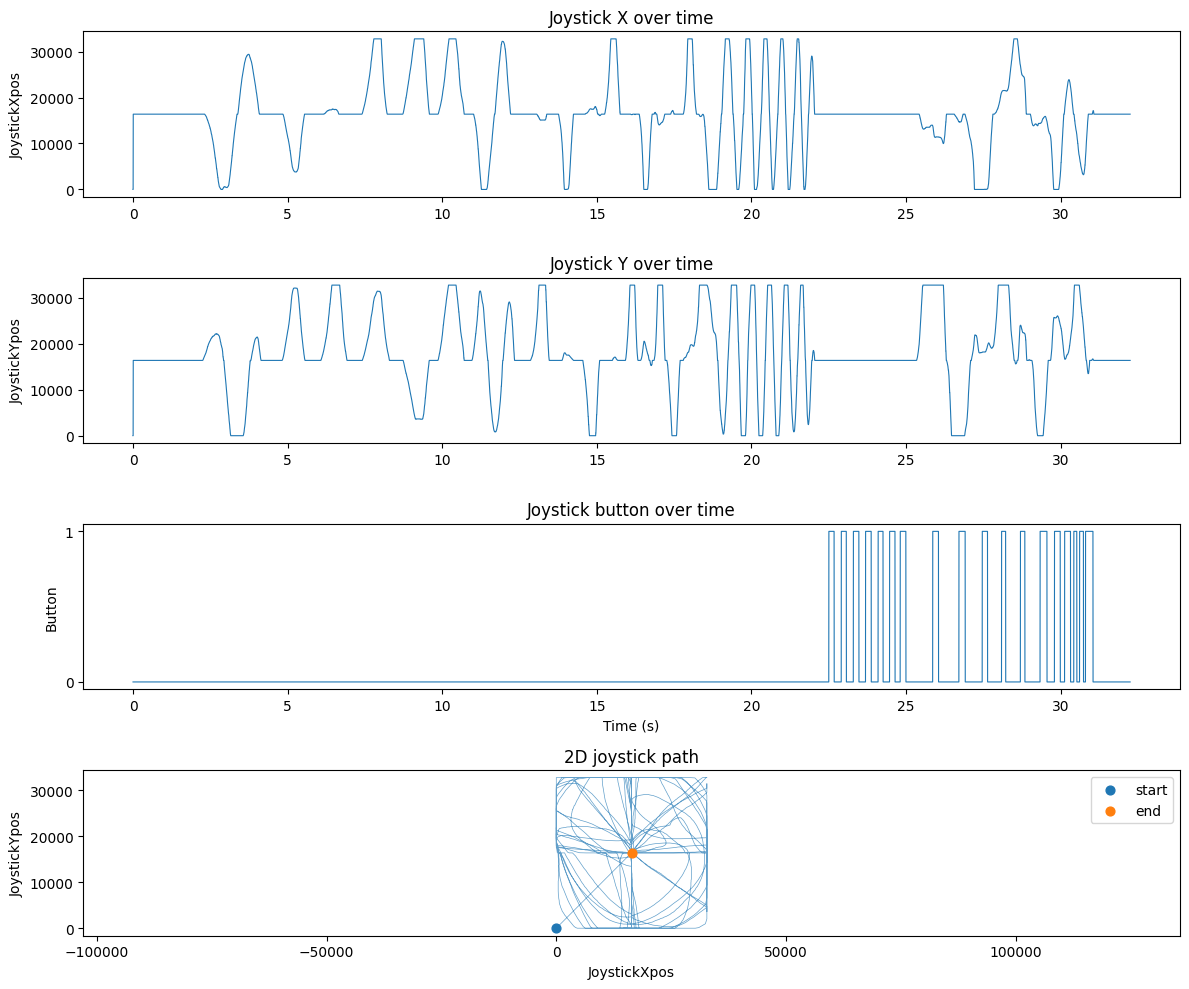

JoystickXpos: min=0, max=32768, unique=660
JoystickYpos: min=0, max=32768, unique=587
JoystickButtons1: min=0, max=1, changes=36


In [6]:
jx = np.asarray(states["JoystickXpos"]).ravel()
jy = np.asarray(states["JoystickYpos"]).ravel()
button = np.asarray(states["JoystickButtons1"]).ravel()

t = np.arange(jx.size) / stream.samplingfreq_hz

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

axes[0].plot(t, jx, lw=0.8)
axes[0].set_ylabel("JoystickXpos")
axes[0].set_title("Joystick X over time")

axes[1].plot(t, jy, lw=0.8)
axes[1].set_ylabel("JoystickYpos")
axes[1].set_title("Joystick Y over time")

axes[2].plot(t, button, lw=0.8)
axes[2].set_ylabel("Button")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Joystick button over time")
axes[2].set_yticks([0, 1])

axes[3].plot(jx, jy, lw=0.5, alpha=0.7)
axes[3].scatter(jx[0], jy[0], s=40, zorder=3, label="start")
axes[3].scatter(jx[-1], jy[-1], s=40, zorder=3, label="end")
axes[3].set_xlabel("JoystickXpos")
axes[3].set_ylabel("JoystickYpos")
axes[3].set_title("2D joystick path")
axes[3].legend()
axes[3].set_aspect("equal", adjustable="datalim")

fig.tight_layout()
plt.show()

print(
    f"JoystickXpos: min={jx.min()}, max={jx.max()}, "
    f"unique={np.unique(jx).size}"
)

print(
    f"JoystickYpos: min={jy.min()}, max={jy.max()}, "
    f"unique={np.unique(jy).size}"
)

print(
    f"JoystickButtons1: min={button.min()}, max={button.max()}, "
    f"changes={np.count_nonzero(np.diff(button))}"
)

In [7]:
channel_names = list(params.get("ChannelNames") or [])

if len(channel_names) != sig.shape[0]:
    channel_names = [
        f"Channel{i + 1}"
        for i in range(sig.shape[0])
    ]

rows = []

for i, name in enumerate(channel_names):
    channel = np.asarray(sig[i]).ravel()

    rows.append({
        "channel": name,
        "min": float(channel.min()),
        "max": float(channel.max()),
        "mean": float(channel.mean()),
        "std": float(channel.std()),
        "n_samples": channel.size,
    })

channel_df = pd.DataFrame(rows).set_index("channel")

channel_df

,min,max,mean,std,n_samples
channel,,,,,
Channel1,-114.700005,114.800003,0.009908,71.210686,8256
Channel2,-114.599998,114.900002,0.011567,71.260956,8256
Channel3,-114.700005,114.800003,0.393847,71.352814,8256
Channel4,-114.700005,114.900002,0.179869,71.215553,8256
Channel5,-114.700005,114.599998,0.140177,71.084801,8256
Channel6,-114.900002,114.900002,0.071609,71.255325,8256
Channel7,-114.300003,114.900002,0.043786,71.188957,8256
Channel8,-114.500000,114.500000,0.006698,71.005020,8256
Channel9,-114.800003,114.800003,0.059314,71.206940,8256
